In [ ]:
!pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.0/79.0 kB 3.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found ex

In [ ]:
import pandas as pd
import snowflake.connector
conn = snowflake.connector.connect(
    user='kavinayac',
    password='',
    account='',
    database='NEO_DB',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'

)
query = 'SELECT * FROM "NEO1"'
data=pd.read_sql(query,conn)
conn.close()
print(data.head())

/tmp/ipython-input-2086542319.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data=pd.read_sql(query,conn)


        ID                 NAME  EST_DIAMETER_MIN  EST_DIAMETER_MAX  \
0  2162635  162635 (2000 SS164)          1.198271          2.679415   
1  2277475    277475 (2005 WK4)          0.265800          0.594347   
2  2512244   512244 (2015 YE18)          0.722030          1.614507   
3  3596030          (2012 BV13)          0.096506          0.215794   
4  3667127          (2014 GE35)          0.255009          0.570217   

   RELATIVE_VELOCITY  MISS_DISTANCE ORBITING_BODY  SENTRY_OBJECT  \
0       13569.249224   5.483974e+07         Earth          False   
1       73588.726663   6.143813e+07         Earth          False   
2      114258.692129   4.979872e+07         Earth          False   
3       24764.303138   2.543497e+07         Earth          False   
4       42737.733765   4.627557e+07         Earth          False   

   ABSOLUTE_MAGNITUDE  HAZARDOUS  
0               16.73      False  
1               20.00       True  
2               17.83      False  
3               22.20   

In [ ]:
x=data.drop(columns=['HAZARDOUS','ORBITING_BODY','SENTRY_OBJECT', 'NAME'])
x

,ID,EST_DIAMETER_MIN,EST_DIAMETER_MAX,RELATIVE_VELOCITY,MISS_DISTANCE,ABSOLUTE_MAGNITUDE
0,2162635,1.198271,2.679415,13569.249224,5.483974e+07,16.73
1,2277475,0.265800,0.594347,73588.726663,6.143813e+07,20.00
2,2512244,0.722030,1.614507,114258.692129,4.979872e+07,17.83
3,3596030,0.096506,0.215794,24764.303138,2.543497e+07,22.20
4,3667127,0.255009,0.570217,42737.733765,4.627557e+07,20.09
...,...,...,...,...,...,...
90831,3763337,0.026580,0.059435,52078.886692,1.230039e+07,25.00
90832,3837603,0.016771,0.037501,46114.605073,5.432121e+07,26.00
90833,54017201,0.031956,0.071456,7566.807732,2.840077e+07,24.60
90834,54115824,0.007321,0.016370,69199.154484,6.869206e+07,27.80


In [ ]:
y=data['HAZARDOUS']
y

,HAZARDOUS
0,False
1,True
2,False
3,False
4,True
...,...
90831,False
90832,False
90833,False
90834,False


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=82)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:

y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.9041721708498459

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[16382,    80],
       [ 1661,    45]])

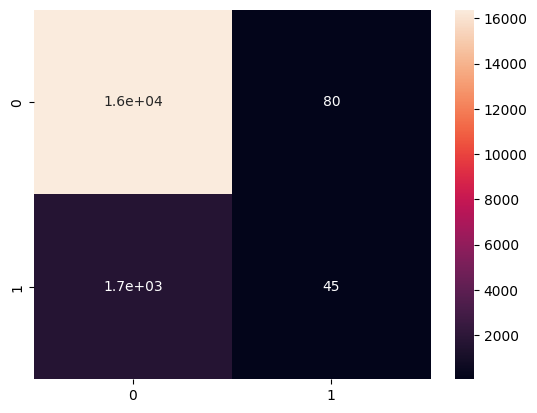

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
confusion_matrix(y_test,y_pred)
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
plt.show()

In [ ]:
import pickle
with open('model.pkl','wb') as f:
    pickle.dump(model,f)

with open('model.pkl', 'rb') as f:
    model = pickle.load(f)


In [ ]:
import joblib
joblib.dump(model, 'model.pkl')
model=joblib.load('model.pkl')